## 13) Fused KPT Head Motion (Left/Right and Up/Down)

Load one person's fused keypoints sequence and compute:
- Left/Right motion from **yaw**
- Up/Down motion from **pitch**

Note: this uses the updated angle logic from `compare_with_human_annotation.angle_calculator`.

Loaded frames: 5199 from /workspace/data/head3d_fuse_results/01/夜多い/fused_npz
Threshold: ±5.0°
Front baseline (pitch, robust): -66.948°
Yaw-based candidates: 2337/5199
Final selected front frames: 779/5199
Yaw (left/right/front) counts:
   left: 4656
  front: 116
  right: 427
Pitch relative to Front (down/front/up) counts:
   down: 1177
  front: 3834
     up: 188


/tmp/ipykernel_2078462/3684228757.py:232: UserWarning: Glyph 22812 (\N{CJK UNIFIED IDEOGRAPH-591C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2078462/3684228757.py:232: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2078462/3684228757.py:232: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/envs/mesh_3d/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22812 (\N{CJK UNIFIED IDEOGRAPH-591C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs/mesh_3d/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs/mesh_3d/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12

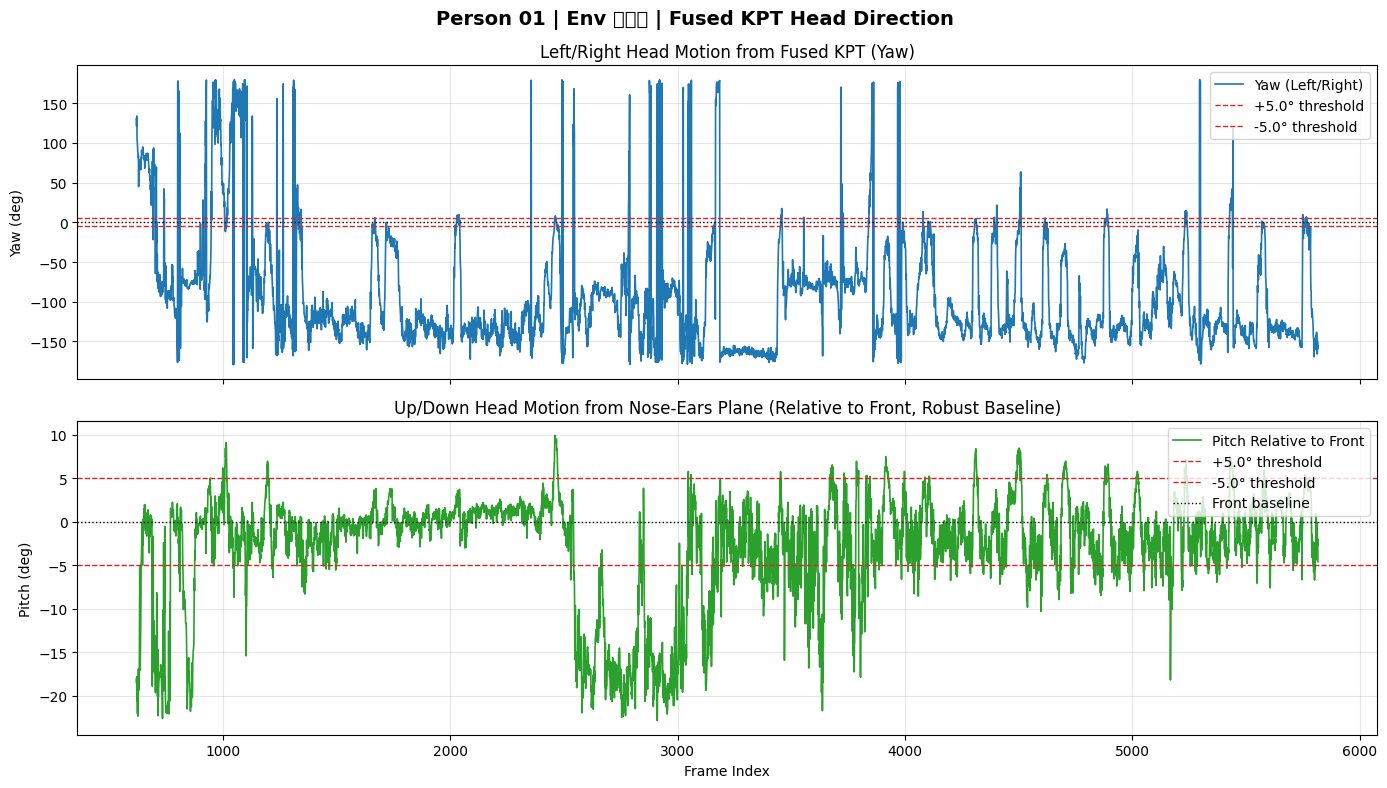

In [4]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

workspace_code = Path('/workspace/code')
if str(workspace_code) not in sys.path:
    sys.path.insert(0, str(workspace_code))

from compare_with_human_annotation.angle_calculator import (
    KEYPOINT_INDICES,
    calculate_head_angles,
    extract_head_keypoints,
)
from compare_with_human_annotation.load import load_fused_keypoints


def calculate_pitch_from_nose_ears_plane(head_keypoints: dict) -> float:
    """基于鼻子+双耳几何计算上下角度（度）。

    1) 取双耳中心 C 与鼻子 N 的向量 v = N - C
    2) 去掉沿耳轴(左耳->右耳)的分量，得到 v_perp
    3) 以 v_perp 与 XY 平面的夹角作为上下角：atan2(v_perp_z, ||v_perp_xy||)

    返回值: up > 0, down < 0
    """
    nose = np.asarray(head_keypoints["nose"], dtype=np.float64)
    left_ear = np.asarray(head_keypoints["left_ear"], dtype=np.float64)
    right_ear = np.asarray(head_keypoints["right_ear"], dtype=np.float64)

    if (
        np.any(np.isnan(nose))
        or np.any(np.isnan(left_ear))
        or np.any(np.isnan(right_ear))
    ):
        return np.nan

    ear_center = 0.5 * (left_ear + right_ear)
    ear_axis = right_ear - left_ear
    ear_norm = np.linalg.norm(ear_axis)
    if ear_norm < 1e-8:
        return np.nan

    ear_axis /= ear_norm
    v = nose - ear_center
    v_perp = v - np.dot(v, ear_axis) * ear_axis

    horiz = np.linalg.norm(v_perp[:2])
    if horiz < 1e-8 and abs(v_perp[2]) < 1e-8:
        return np.nan

    return float(np.degrees(np.arctan2(v_perp[2], horiz)))


def estimate_stable_front_baseline(
    raw_pitch_vals: np.ndarray,
    yaw_vals: np.ndarray,
    front_ratio: float = 0.15,
    min_front_frames: int = 30,
    candidate_expand: float = 3.0,
    mad_k: float = 2.5,
    max_iters: int = 5,
) -> tuple[float, np.ndarray, np.ndarray]:
    """稳健估计front基线。

    步骤:
    1) 按 |yaw| 从小到大取候选（先放宽到 candidate_expand 倍）
    2) 在候选内对 raw_pitch 做中位数 + MAD 迭代去异常
    3) 从最终内点里取最接近中心的 n_front 帧，基线取中位数
    """
    n_frames = len(raw_pitch_vals)
    n_front = max(min_front_frames, int(n_frames * front_ratio))
    n_front = min(n_front, n_frames)

    n_candidates = min(n_frames, max(n_front, int(n_front * candidate_expand)))
    candidate_idx = np.argsort(np.abs(yaw_vals))[:n_candidates]
    candidate_pitch = raw_pitch_vals[candidate_idx]

    center = float(np.median(candidate_pitch))
    inlier_mask = np.ones(candidate_pitch.shape[0], dtype=bool)

    for _ in range(max_iters):
        working = candidate_pitch[inlier_mask]
        if working.size == 0:
            break

        new_center = float(np.median(working))
        mad = float(np.median(np.abs(working - new_center)))
        robust_sigma = max(1e-6, 1.4826 * mad)

        new_inlier_mask = np.abs(candidate_pitch - new_center) <= mad_k * robust_sigma

        if np.all(new_inlier_mask == inlier_mask):
            center = new_center
            inlier_mask = new_inlier_mask
            break

        center = new_center
        inlier_mask = new_inlier_mask

    inlier_idx = candidate_idx[inlier_mask]

    # 防止内点太少：回退为最小|yaw|的n_front帧
    if inlier_idx.size < min(10, n_front):
        selected_idx = np.argsort(np.abs(yaw_vals))[:n_front]
    else:
        inlier_pitch = raw_pitch_vals[inlier_idx]
        selected_order = np.argsort(np.abs(inlier_pitch - center))
        selected_idx = inlier_idx[selected_order[: min(n_front, inlier_idx.size)]]

    baseline = float(np.median(raw_pitch_vals[selected_idx]))
    return baseline, selected_idx, candidate_idx


# -----------------------------
# Parameters
# -----------------------------
person_id = '01'
env_name = '夜多い'  # e.g. 昼多い / 昼少ない / 夜多い / 夜少ない
fused_root = Path('/workspace/data/head3d_fuse_results')
fused_dir = fused_root / person_id / env_name / 'fused_npz'
threshold_deg = 5.0

# front基准估计参数
front_ratio = 0.15
min_front_frames = 30

if not fused_dir.exists():
    raise FileNotFoundError(f'Fused directory not found: {fused_dir}')

# -----------------------------
# Pass-1: Load sequence and compute raw yaw/raw pitch
# -----------------------------
pattern = re.compile(r'^frame_(\d+)_fused\.npy$')
records = []

for npy_path in sorted(fused_dir.glob('frame_*_fused.npy')):
    m = pattern.match(npy_path.name)
    if m is None:
        continue

    frame_idx = int(m.group(1))
    kpts3d = load_fused_keypoints(npy_path)
    if kpts3d is None:
        continue

    head_kpts = extract_head_keypoints(kpts3d, KEYPOINT_INDICES)
    if head_kpts is None:
        continue

    _, yaw = calculate_head_angles(head_kpts)
    raw_pitch = calculate_pitch_from_nose_ears_plane(head_kpts)
    if np.isnan(raw_pitch) or np.isnan(yaw):
        continue

    records.append((frame_idx, raw_pitch, yaw))

if not records:
    raise RuntimeError(f'No valid fused frames found in: {fused_dir}')

records.sort(key=lambda x: x[0])
frames = np.array([r[0] for r in records], dtype=np.int32)
raw_pitch_vals = np.array([r[1] for r in records], dtype=np.float64)
yaw_vals = np.array([r[2] for r in records], dtype=np.float64)

# -----------------------------
# Pass-2: Robust front baseline -> relative pitch
# -----------------------------
front_pitch_baseline, selected_front_idx, yaw_candidate_idx = estimate_stable_front_baseline(
    raw_pitch_vals=raw_pitch_vals,
    yaw_vals=yaw_vals,
    front_ratio=front_ratio,
    min_front_frames=min_front_frames,
)

# 最终用于up/down的是相对front角度
pitch_vals = raw_pitch_vals - front_pitch_baseline

# Motion direction classification by threshold
yaw_dir = np.where(
    yaw_vals > threshold_deg,
    'right',
    np.where(yaw_vals < -threshold_deg, 'left', 'front')
)
pitch_dir = np.where(
    pitch_vals > threshold_deg,
    'up',
    np.where(pitch_vals < -threshold_deg, 'down', 'front')
)

print(f'Loaded frames: {len(frames)} from {fused_dir}')
print(f'Threshold: ±{threshold_deg:.1f}°')
print(f'Front baseline (pitch, robust): {front_pitch_baseline:.3f}°')
print(f'Yaw-based candidates: {len(yaw_candidate_idx)}/{len(frames)}')
print(f'Final selected front frames: {len(selected_front_idx)}/{len(frames)}')
print('Yaw (left/right/front) counts:')
for label in ['left', 'front', 'right']:
    print(f'  {label:>5}: {int(np.sum(yaw_dir == label))}')
print('Pitch relative to Front (down/front/up) counts:')
for label in ['down', 'front', 'up']:
    print(f'  {label:>5}: {int(np.sum(pitch_dir == label))}')

# -----------------------------
# Visualization
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Left/Right by yaw
axes[0].plot(frames, yaw_vals, color='tab:blue', linewidth=1.2, label='Yaw (Left/Right)')
axes[0].axhline(threshold_deg, color='tab:red', linestyle='--', linewidth=1.0, label=f'+{threshold_deg:.1f}° threshold')
axes[0].axhline(-threshold_deg, color='tab:red', linestyle='--', linewidth=1.0, label=f'-{threshold_deg:.1f}° threshold')
axes[0].axhline(0.0, color='black', linestyle=':', linewidth=1.0)
axes[0].set_ylabel('Yaw (deg)')
axes[0].set_title('Left/Right Head Motion from Fused KPT (Yaw)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

# Up/Down by pitch relative to front
axes[1].plot(frames, pitch_vals, color='tab:green', linewidth=1.2, label='Pitch Relative to Front')
axes[1].axhline(threshold_deg, color='tab:red', linestyle='--', linewidth=1.0, label=f'+{threshold_deg:.1f}° threshold')
axes[1].axhline(-threshold_deg, color='tab:red', linestyle='--', linewidth=1.0, label=f'-{threshold_deg:.1f}° threshold')
axes[1].axhline(0.0, color='black', linestyle=':', linewidth=1.0, label='Front baseline')
axes[1].set_ylabel('Pitch (deg)')
axes[1].set_xlabel('Frame Index')
axes[1].set_title('Up/Down Head Motion from Nose-Ears Plane (Relative to Front, Robust Baseline)')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

fig.suptitle(f'Person {person_id} | Env {env_name} | Fused KPT Head Direction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 14) 同一人的三位标注者时间轴可视化

读取 `data/annotation/label/full.json`，将同一人的三个标注者结果按时间轴画在三条轨道上。

Video ID: 01_night_high
Annotators loaded: 3
Majority-voted segments (4 labels only): 99
Filtered labels: ['down', 'left', 'right', 'up']


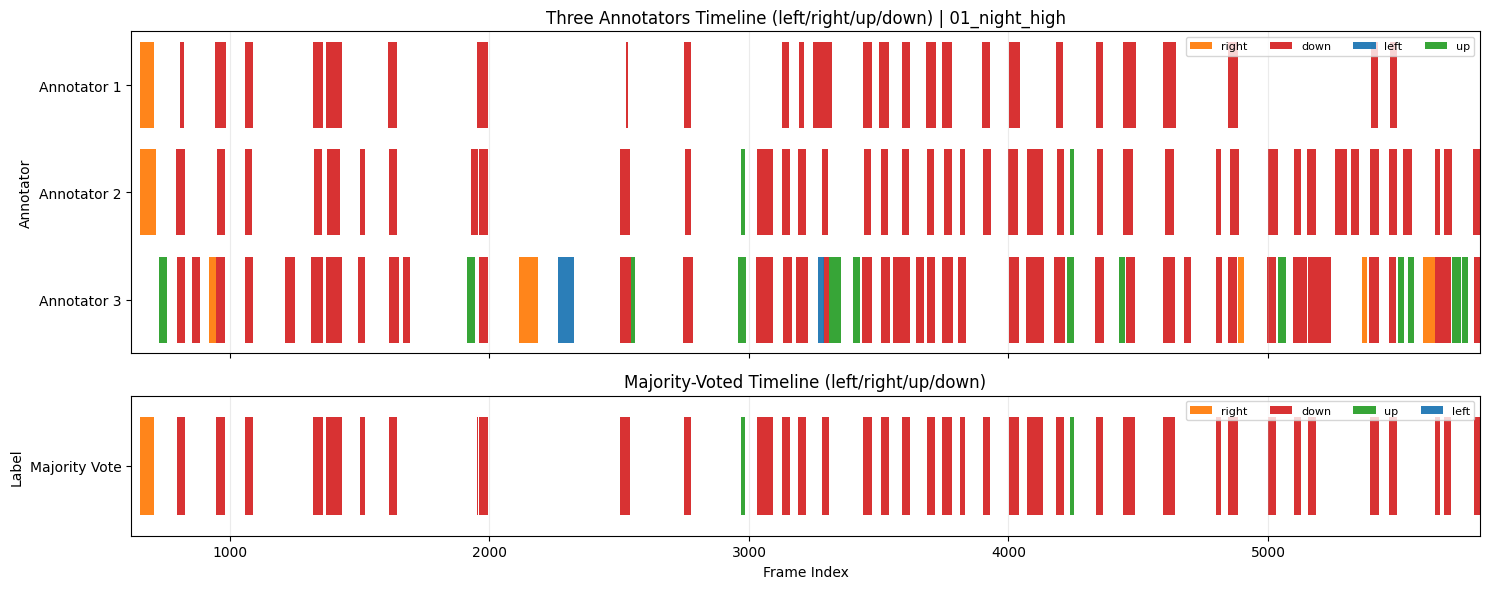

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt

from compare_with_human_annotation.load import (
    load_annotations_by_annotator,
    load_majority_voted_annotations,
)


def build_video_id(person_id: str, env_name: str) -> str:
    env_map = {
        '昼多い': 'day_high',
        '昼少ない': 'day_low',
        '夜多い': 'night_high',
        '夜少ない': 'night_low',
    }
    if env_name not in env_map:
        raise ValueError(f'Unsupported env_name: {env_name}')
    return f'{person_id}_{env_map[env_name]}'


VALID_LABELS = {'left', 'right', 'up', 'down'}


def label_spans(one_annotator_labels):
    spans = []
    for ann in one_annotator_labels:
        label = str(ann.label).lower()
        if label not in VALID_LABELS:
            continue
        start = int(ann.start_frame)
        end = int(ann.end_frame)
        if end < start:
            continue
        spans.append((start, end - start + 1, label))
    return spans


annotation_json = Path('/workspace/data/annotation/label/full.json')
video_id = build_video_id(person_id, env_name)

annotations_by_video = load_annotations_by_annotator(annotation_json)
labels_by_annotator = annotations_by_video.get(video_id, [])

majority_annotations_by_video = load_majority_voted_annotations(annotation_json)
majority_labels = majority_annotations_by_video.get(video_id, [])
majority_spans = label_spans(majority_labels)

print(f'Video ID: {video_id}')
print(f'Annotators loaded: {len(labels_by_annotator)}')
print(f'Majority-voted segments (4 labels only): {len(majority_spans)}')
print(f'Filtered labels: {sorted(VALID_LABELS)}')

label_colors = {
    'left': '#1f77b4',
    'right': '#ff7f0e',
    'up': '#2ca02c',
    'down': '#d62728',
}

fig, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(15, 6.0),
    sharex=True,
    gridspec_kw={'height_ratios': [2.3, 1.0]},
)
legend_added = set()

# 上图：三位标注者
if labels_by_annotator:
    n_annotators = len(labels_by_annotator)
    for i, one_annotator_labels in enumerate(labels_by_annotator, start=1):
        y_base = n_annotators - i
        for start, width, label in label_spans(one_annotator_labels):
            color = label_colors[label]
            show_label = label if label not in legend_added else None
            ax_top.broken_barh(
                [(start, width)],
                (y_base + 0.1, 0.8),
                facecolors=color,
                alpha=0.95,
                label=show_label,
            )
            legend_added.add(label)

    ax_top.set_yticks([idx + 0.5 for idx in range(n_annotators)])
    ax_top.set_yticklabels([f'Annotator {n_annotators - idx}' for idx in range(n_annotators)])
    ax_top.set_ylim(0, n_annotators)
    ax_top.set_ylabel('Annotator')
    ax_top.set_title(f'Three Annotators Timeline (left/right/up/down) | {video_id}')
    ax_top.grid(True, axis='x', alpha=0.25)
    if legend_added:
        ax_top.legend(loc='upper right', ncol=4, fontsize=8)
else:
    ax_top.text(
        0.5,
        0.5,
        f'No annotations found for {video_id}',
        ha='center',
        va='center',
        transform=ax_top.transAxes,
    )
    ax_top.set_yticks([])
    ax_top.set_title(f'Three Annotators Timeline (left/right/up/down) | {video_id}')

# 下图：多数投票
legend_added_bottom = set()
if majority_spans:
    for start, width, label in majority_spans:
        color = label_colors[label]
        show_label = label if label not in legend_added_bottom else None
        ax_bottom.broken_barh(
            [(start, width)],
            (0.15, 0.7),
            facecolors=color,
            alpha=0.95,
            label=show_label,
        )
        legend_added_bottom.add(label)

    ax_bottom.set_yticks([0.5])
    ax_bottom.set_yticklabels(['Majority Vote'])
    ax_bottom.set_ylim(0, 1)
    ax_bottom.set_ylabel('Label')
    ax_bottom.set_title('Majority-Voted Timeline (left/right/up/down)')
    ax_bottom.grid(True, axis='x', alpha=0.25)
    if legend_added_bottom:
        ax_bottom.legend(loc='upper right', ncol=4, fontsize=8)
else:
    ax_bottom.text(
        0.5,
        0.5,
        f'No majority-voted labels found for {video_id}',
        ha='center',
        va='center',
        transform=ax_bottom.transAxes,
    )
    ax_bottom.set_yticks([])
    ax_bottom.set_title('Majority-Voted Timeline (left/right/up/down)')

if 'frames' in globals() and len(frames) > 0:
    xmin, xmax = int(frames.min()), int(frames.max())
    ax_top.set_xlim(xmin, xmax)

ax_bottom.set_xlabel('Frame Index')

plt.tight_layout()
plt.show()

Video ID: 01_night_high
Common labeled frames: 1294

[Yaw / Left-Right only]
  Eval frames: 54
  Agreement: 94.4%
  majority  left:     0 (  0.0%) | angle  left:     3 (  5.6%)
  majority right:    54 (100.0%) | angle right:    51 ( 94.4%)
  angle front:     0 (  0.0%)

[Pitch / Up-Down only]
  Eval frames: 1240
  Agreement: 17.9%
  majority    up:    31 (  2.5%) | angle    up:    39 (  3.1%)
  majority  down:  1209 ( 97.5%) | angle  down:   240 ( 19.4%)
  angle front:   961 ( 77.5%)

Front baseline used in angle plot: -66.948°


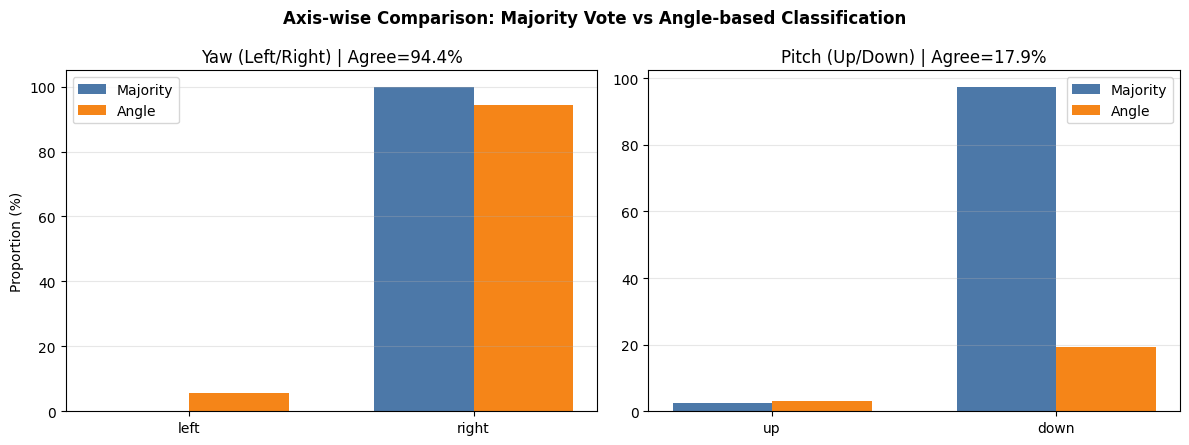

In [6]:
from collections import Counter


YAW_LABELS = ['left', 'right']
PITCH_LABELS = ['up', 'down']


def spans_to_frame_labels(spans):
    frame_labels = {}
    for start, width, label in spans:
        for frame_idx in range(start, start + width):
            frame_labels[frame_idx] = label
    return frame_labels


def yaw_label_from_value(yaw_value: float, threshold: float) -> str:
    if yaw_value > threshold:
        return 'right'
    if yaw_value < -threshold:
        return 'left'
    return 'front'


def pitch_label_from_value(pitch_value: float, threshold: float) -> str:
    if pitch_value > threshold:
        return 'up'
    if pitch_value < -threshold:
        return 'down'
    return 'front'


if 'majority_spans' not in globals():
    raise RuntimeError('majority_spans is not available; run the previous cell first.')
if 'frames' not in globals() or 'pitch_vals' not in globals() or 'yaw_vals' not in globals():
    raise RuntimeError('frames/pitch_vals/yaw_vals are not available; run the fused motion cell first.')

majority_frame_labels = spans_to_frame_labels(majority_spans)
frame_to_idx = {int(frame_idx): idx for idx, frame_idx in enumerate(frames)}
common_frames = sorted(set(majority_frame_labels.keys()) & set(frame_to_idx.keys()))

if not common_frames:
    raise RuntimeError('No overlapping frames between majority-voted labels and angle sequence.')

# -----------------------------
# 分轴统计：Yaw(左右) 与 Pitch(上下)
# -----------------------------
yaw_majority_counts = Counter()
yaw_angle_counts = Counter()
yaw_front_count = 0
yaw_eval_count = 0
yaw_agree_count = 0

pitch_majority_counts = Counter()
pitch_angle_counts = Counter()
pitch_front_count = 0
pitch_eval_count = 0
pitch_agree_count = 0

for frame_idx in common_frames:
    majority_label = majority_frame_labels[frame_idx]
    idx = frame_to_idx[frame_idx]
    yaw_pred = yaw_label_from_value(float(yaw_vals[idx]), threshold_deg)
    pitch_pred = pitch_label_from_value(float(pitch_vals[idx]), threshold_deg)

    # 左右比较（只在 majority 标为 left/right 的帧上评估）
    if majority_label in YAW_LABELS:
        yaw_eval_count += 1
        yaw_majority_counts[majority_label] += 1
        if yaw_pred == 'front':
            yaw_front_count += 1
        else:
            yaw_angle_counts[yaw_pred] += 1
        if yaw_pred == majority_label:
            yaw_agree_count += 1

    # 上下比较（只在 majority 标为 up/down 的帧上评估）
    if majority_label in PITCH_LABELS:
        pitch_eval_count += 1
        pitch_majority_counts[majority_label] += 1
        if pitch_pred == 'front':
            pitch_front_count += 1
        else:
            pitch_angle_counts[pitch_pred] += 1
        if pitch_pred == majority_label:
            pitch_agree_count += 1

# 百分比辅助函数
def pct(count: int, total: int) -> float:
    return (count / total * 100.0) if total > 0 else 0.0

print(f'Video ID: {video_id}')
print(f'Common labeled frames: {len(common_frames)}')
print('')
print('[Yaw / Left-Right only]')
print(f'  Eval frames: {yaw_eval_count}')
print(f'  Agreement: {pct(yaw_agree_count, yaw_eval_count):.1f}%')
for label in YAW_LABELS:
    print(
        f'  majority {label:>5}: {yaw_majority_counts[label]:5d} '
        f'({pct(yaw_majority_counts[label], yaw_eval_count):5.1f}%) | '
        f'angle {label:>5}: {yaw_angle_counts[label]:5d} '
        f'({pct(yaw_angle_counts[label], yaw_eval_count):5.1f}%)'
    )
print(f"  angle front: {yaw_front_count:5d} ({pct(yaw_front_count, yaw_eval_count):5.1f}%)")
print('')
print('[Pitch / Up-Down only]')
print(f'  Eval frames: {pitch_eval_count}')
print(f'  Agreement: {pct(pitch_agree_count, pitch_eval_count):.1f}%')
for label in PITCH_LABELS:
    print(
        f'  majority {label:>5}: {pitch_majority_counts[label]:5d} '
        f'({pct(pitch_majority_counts[label], pitch_eval_count):5.1f}%) | '
        f'angle {label:>5}: {pitch_angle_counts[label]:5d} '
        f'({pct(pitch_angle_counts[label], pitch_eval_count):5.1f}%)'
    )
print(f"  angle front: {pitch_front_count:5d} ({pct(pitch_front_count, pitch_eval_count):5.1f}%)")
print('')
print(f'Front baseline used in angle plot: {front_pitch_baseline:.3f}°')

# -----------------------------
# 可视化：分轴柱状图
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Yaw subplot
x0 = np.arange(len(YAW_LABELS))
w = 0.35
maj_yaw_pct = [pct(yaw_majority_counts[label], yaw_eval_count) for label in YAW_LABELS]
ang_yaw_pct = [pct(yaw_angle_counts[label], yaw_eval_count) for label in YAW_LABELS]
axes[0].bar(x0 - w / 2, maj_yaw_pct, w, label='Majority', color='#4c78a8')
axes[0].bar(x0 + w / 2, ang_yaw_pct, w, label='Angle', color='#f58518')
axes[0].set_xticks(x0)
axes[0].set_xticklabels(YAW_LABELS)
axes[0].set_title(f'Yaw (Left/Right) | Agree={pct(yaw_agree_count, yaw_eval_count):.1f}%')
axes[0].set_ylabel('Proportion (%)')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].legend()

# Pitch subplot
x1 = np.arange(len(PITCH_LABELS))
maj_pitch_pct = [pct(pitch_majority_counts[label], pitch_eval_count) for label in PITCH_LABELS]
ang_pitch_pct = [pct(pitch_angle_counts[label], pitch_eval_count) for label in PITCH_LABELS]
axes[1].bar(x1 - w / 2, maj_pitch_pct, w, label='Majority', color='#4c78a8')
axes[1].bar(x1 + w / 2, ang_pitch_pct, w, label='Angle', color='#f58518')
axes[1].set_xticks(x1)
axes[1].set_xticklabels(PITCH_LABELS)
axes[1].set_title(f'Pitch (Up/Down) | Agree={pct(pitch_agree_count, pitch_eval_count):.1f}%')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend()

fig.suptitle('Axis-wise Comparison: Majority Vote vs Angle-based Classification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()